# Setups

In [15]:
! pip install sentence-transformers langchain-huggingface

Python(98006) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


zsh:1: /Users/nguyencongkhanh/Documents/MLDL/RAG_and_langchain/from_scratch_rag/.venv/bin/pip: bad interpreter: /Users/nguyencongkhanh/Documents/MLDL/RAG_and_langchain/from_scratch/.venv/bin/python3.11: no such file or directory


In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

# Enable LangSmith tracing if you want runs logged
os.environ.setdefault('LANGCHAIN_TRACING_V2', 'true')

# If you use a regional deployment, set LANGSMITH_ENDPOINT (or LANGCHAIN_ENDPOINT) in .env
# Example: LANGSMITH_ENDPOINT=https://api.smith.langchain.com

# Some LangChain/LangSmith code paths still check LANGCHAIN_API_KEY.
if os.getenv('LANGCHAIN_API_KEY') is None and os.getenv('LANGSMITH_API_KEY'):
    os.environ['LANGCHAIN_API_KEY'] = os.environ['LANGSMITH_API_KEY']

if not (os.getenv('LANGSMITH_API_KEY') or os.getenv('LANGCHAIN_API_KEY')):
    raise RuntimeError('Missing LangSmith API key: set LANGSMITH_API_KEY (or LANGCHAIN_API_KEY) in .env')


# Part 1: Overview

In [1]:
import bs4 
from langchain_classic import hub
from langsmith import Client
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_classic.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
#go through all import statement and view their documentation

/Users/nguyencongkhanh/Documents/MLDL/RAG_and_langchain/from_scratch_rag/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [18]:
from google import genai

client = genai.Client()

model_list = client.models.list()

for i in range(0,10):
    model = model_list[i]
    modelsss = model.display_name
    if "embedding" in modelsss:
        print(model)

In [19]:
os.environ['LANGSMITH_PROJECT'] = "rag_from_scratch"
#load documents
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",), #blog post
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)

docs = loader.load()
#split documents into chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
texts = text_splitter.split_documents(docs)

#embed documents
embedding_models = HuggingFaceEmbeddings(model="all-MiniLM-L6-v2")
vector_store = Chroma.from_documents(documents=texts,
                                     embedding=embedding_models,
                                     collection_name="minilm_embeddings") #384-dimension db

retriever = vector_store.as_retriever()

###Retrieval and Generation

prompt_temp = """Answer the {question} based on given {context}"""

prompt = ChatPromptTemplate.from_template(prompt_temp)


llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

#formating the docs

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs )

# Chain
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough() }
    | prompt
    | llm
    | StrOutputParser()
)

rag_chain.invoke("What is Task Decomposition")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4018.09it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


'Based on the provided text, **Task Decomposition** refers to the process of breaking down a task or problem into smaller, more manageable steps or subgoals.\n\nIt can be achieved through several methods:\n1.  **Using Large Language Models (LLMs) with simple prompting:** This involves asking the LLM directly for steps (e.g., "Steps for XYZ.") or subgoals (e.g., "What are the subgoals for achieving XYZ?").\n2.  **Using task-specific instructions:** This involves providing the LLM with specific directives tailored to the task, such as "Write a story outline" for a novel.\n3.  **With human inputs:** Humans can directly provide the decomposition.\n\nA distinct approach, **LLM+P (Liu et al. 2023)**, involves outsourcing long-horizon planning to an external classical planner. In this method:\n*   The LLM translates the problem into "Problem PDDL" (Planning Domain Definition Language).\n*   It then requests the classical planner to generate a PDDL plan based on an existing "Domain PDDL."\n*  

## 2. Indexing

In [2]:
#Documents
question = "What is your name?"
document = "acdefg"

In [3]:
#compute number of tokens
import tiktoken

def nums_tokens_from_string(string: str, encoding_name: str) -> int:
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    print(encoding)

    return num_tokens

nums_tokens_from_string(question, "cl100k_base")

#figure how large the documents we feed in embedding model
#find out about cl100k_base tokenisation


<Encoding 'cl100k_base'>


5

In [4]:
from langchain_huggingface import HuggingFaceEmbeddings
embd = HuggingFaceEmbeddings()
query_res = embd.embed_query(question)
doc_res = embd.embed_query(document)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 480.75it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
print(len(query_res))
print(len(doc_res))

768
768


In [6]:
#cosine similarity

import numpy as np

def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)

    return dot_product / (norm_vec1 * norm_vec2)

simil = cosine_similarity(query_res, doc_res)
print("Consine Similarity: ", simil)

Consine Similarity:  0.1897756450010731


Work with our document

## 3. Retriever

In [25]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

vector_store_2 = Chroma.from_documents(documents = texts,
                        embedding=HuggingFaceEmbeddings())

retriever_knn = vector_store_2.as_retriever(kwargs={'k': 1}) #knn setting number of neighbours choose

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4478.95it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KeyboardInterrupt: 

In [26]:
docs = retriever_knn.invoke("What is Task Decomposition?")

NameError: name 'retriever_knn' is not defined

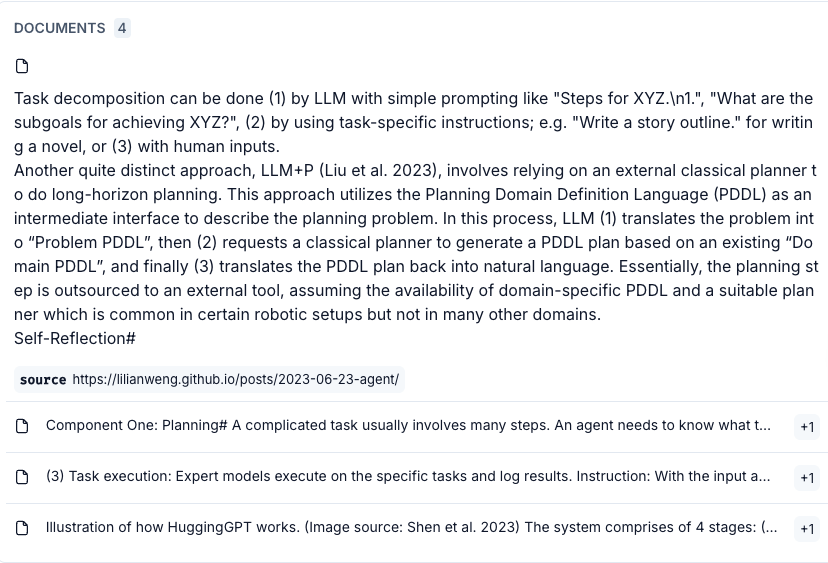

In [ ]:
docs = retriever_knn.invoke("What is Task Decomposition?")

In [ ]:
len(docs)

4

## Generation

In [ ]:
#from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate

#prompt template - we create a template for our prompt which we will populate using the dict containing questions and context

template = """Answer the question based only on the following context:
{context}

Question: {question}
""" 

prompt2 = ChatPromptTemplate.from_template(template)
prompt2

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Answer the question based only on the following context:\n{context}\n\nQuestion: {question}\n'), additional_kwargs={})])

In [ ]:
#LLM
llm_2 = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0) #retrieve accurate answers

In [ ]:
#chain 
#langchain expression language

chain = prompt2 | llm

In [ ]:
chain.invoke({"context": docs,"question": "What is Task Decomposition?"})

AIMessage(content='Task decomposition is the process of breaking down complex or hard tasks into smaller, simpler, and more manageable steps.\n\nIt can be done in several ways:\n1.  By an LLM (Large Language Model) with simple prompting, such as "Steps for XYZ." or "What are the subgoals for achieving XYZ?".\n2.  By using task-specific instructions; for example, "Write a story outline" for writing a novel.\n3.  With human inputs.\n\nChain of Thought (CoT) is a standard prompting technique that enhances model performance on complex tasks by instructing the model to "think step by step" to decompose them.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d1722-c6a8-7ce2-bd96-9dcae0829391-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 825, 'output_tokens': 620, 'total_tokens': 1445, 'input_token_details': {'cache_read': 0}, 'output_token_de

### Finally from this we create a basic RAG chain

In [ ]:
from langchain_classic import hub
prompt_hub_rag = hub.pull("rlm/rag-prompt")

print(prompt_hub_rag)

from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

rag_chain = (
    {"context": retriever_knn,"question": RunnablePassthrough()}
    | prompt
    | llm_2
    | StrOutputParser()
)

rag_chain.invoke("What is Task Decomposition?")

input_variables=['context', 'question'] input_types={} partial_variables={} metadata={'lc_hub_owner': 'rlm', 'lc_hub_repo': 'rag-prompt', 'lc_hub_commit_hash': '50442af133e61576e74536c6556cefe1fac147cad032f4377b60c436e6cdcb6e'} messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"), additional_kwargs={})]


'Task decomposition is the process of breaking down a complicated task into smaller, simpler, and more manageable steps. This allows an agent to plan ahead and makes complex tasks easier to handle. It can be achieved through methods like LLM prompting (e.g., Chain of Thought), task-specific instructions, or human input.'

Failed to refresh cache entry rlm/rag-prompt: Resource not found for /commits/rlm/rag-prompt/latest. HTTPError('404 Client Error: Not Found for url: https://eu.api.smith.langchain.com/commits/rlm/rag-prompt/latest', '{"error":"Commit not found"}\n')
Failed to refresh cache entry rlm/rag-prompt: Resource not found for /commits/rlm/rag-prompt/latest. HTTPError('404 Client Error: Not Found for url: https://eu.api.smith.langchain.com/commits/rlm/rag-prompt/latest', '{"error":"Commit not found"}\n')


In [ ]:
#some random question

rag_chain.invoke("What day was the blog posted?")

Failed to refresh cache entry rlm/rag-prompt: Resource not found for /commits/rlm/rag-prompt/latest. HTTPError('404 Client Error: Not Found for url: https://eu.api.smith.langchain.com/commits/rlm/rag-prompt/latest', '{"error":"Commit not found"}\n')


# Part 2: Multi Query


### Load documents

In [7]:
import spacy

nlp = spacy.load("en_core_web_sm")

doc = nlp("Backpropagation is beautiful.")
for token in doc:
    print(token.text, token.pos_)

Backpropagation NOUN
is AUX
beautiful ADJ
. PUNCT


In [9]:
from langchain_community.document_loaders import SeleniumURLLoader

urls = ["https://www.3blue1brown.com/lessons/backpropagation-calculus"]

strainer = bs4.SoupStrainer(class_=("MarkdownBlock", "lesson-header"))

loader = WebBaseLoader(
    web_path="https://www.3blue1brown.com/lessons/backpropagation-calculus",
    bs_kwargs={"parse_only": strainer}
)

sele_loader = SeleniumURLLoader(urls=urls)


docs = sele_loader.load()



In [10]:
print(docs[0].page_content[:1000])

Neural Networks

Chapter 5Backpropagation calculus

Published 3 Nov 2017

Updated 22 Mar 2026

Lesson by Grant Sanderson

Text adaptation by Josh Pullen

Source Code

The hard assumption here is that you’ve read the previous part, giving an intuitive walkthrough of the backpropagation algorithm. Here, we get a bit more formal and dive into the relevant calculus. It’s normal for this to be a little confusing, so be sure to pause and ponder throughout.

As a quick reminder, backpropagation is an algorithm for calculating the gradient of the cost function of a network.

∇C=⎣⎡​∂w(1)∂C​∂b(1)∂C​⋮∂w(L)∂C​∂b(L)∂C​​⎦⎤​

The entries of the gradient vector are the partial derivatives of the cost function with respect to all the different weights and biases of the network, so it’s really those derivatives that backpropagation helps us find.

In the last lesson we talked about the intuitive feeling you might have for how backpropagation works, so now our focus will be on connecting that intuition w

### Indexing + Splitting

In [11]:
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200, 
    chunk_overlap=250)

texts = text_splitter.split_documents(docs)

#embed documents
embedding_models = HuggingFaceEmbeddings(model="all-MiniLM-L6-v2")
vector_store_3b1b_paper = Chroma.from_documents(documents=texts,
                                     embedding=embedding_models,
                                     collection_name="minilm_embeddings") #384-dimension db

retriever_3b1b = vector_store_3b1b_paper.as_retriever()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 232.49it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
with open('my_system_prompt_simple.txt') as f:
    better_template = f.read()
    f.close()

print(better_template)

You are an AI LLM assistant. You are assigned to generate five different versions of the give user question to retrieve relevant documents from a vector database. By generating multiple persepectives on the user question, your goal is to help the user overcome some of the limitations of the distance-based similarity search. Provide these alternative questions separated by newlines. Original question: {question}


In [13]:
#reframe questions into subquestions

from langchain_core.prompts import ChatPromptTemplate

# set up new prompt for multi query
better_template = """
You are an AI LLM assistant. You are assigned to generate five different versions of the give user question to retrieve relevant documents from a vector database. By generating multiple persepectives on the user question, your goal is to help the user overcome some of the limitations of the distance-based similarity search. Provide these alternative questions separated by newlines. Original question: {question}
"""



prompt_perspecitves = ChatPromptTemplate.from_template(better_template)

generated_queries = (
    prompt_perspecitves 
    | ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature=0)
    | StrOutputParser() 
    | (lambda x: x.split("\n")) #split by new lines
)
#return a list of questions


In [14]:
from langchain_core.load import dumps, loads

def get_unique_union(documents: list[list]):
    # Flatten list of lists, and convert each Document to a string
    flattened_docs = [dumps(doc) for sublist in documents for doc in sublist]
    
    # Get unique documents by putting them in a set
    unique_docs = list(set(flattened_docs))

    # Convert back to Document objects

    return [loads(doc) for doc in unique_docs]



In [15]:
question = "What is the definition of backpropagation?"

retrieval_chain = generated_queries | retriever_3b1b.map() | get_unique_union

docs = retrieval_chain.invoke({"question": question})

print(len(docs))

/var/folders/gh/ljk42ycd2j75q25hbk1sggv80000gn/T/ipykernel_58762/3912310087.py:12: LangChainBetaWarning: The function `loads` is in beta. It is actively being worked on, so the API may change.
  return [loads(doc) for doc in unique_docs]


18


![Screenshot 2026-03-23 at 17.40.52.png](<attachment:Screenshot 2026-03-23 at 17.40.52.png>)

- Subquestions breakdown by LLM
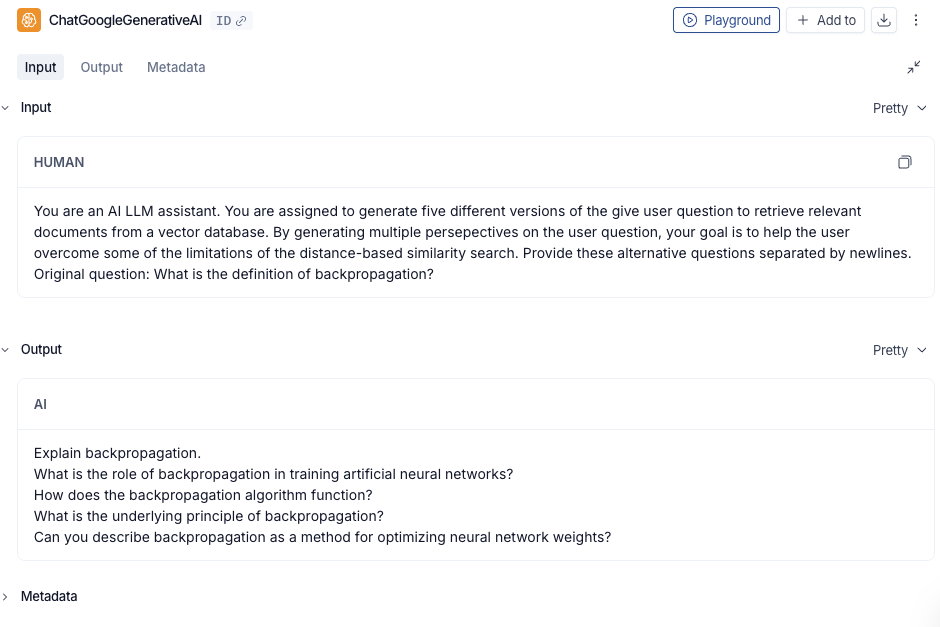

In [16]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough

#RAG 

template = """ Answer the following question based on this context:

{context}

Question: {question}

"""

prompt = ChatPromptTemplate.from_template(template)

llm_called = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

rag_chainz = (
    {"context": retrieval_chain,
     "question": itemgetter("question")}
     | prompt
     | llm_called
     | StrOutputParser()
)

rag_chainz.invoke({"question":question})

'Backpropagation is an algorithm for calculating the gradient of the cost function of a network. It is the algorithm by which neural networks learn. The entries of the gradient vector are the partial derivatives of the cost function with respect to all the different weights and biases of the network, which backpropagation helps to find.'

## Rag Fusion

### Prompt

In [17]:
from langchain_classic.prompts import ChatPromptTemplate

#RAG-Fusion: Template

template = """You are an amazingly, superior, best AI assistant that generates multiple search queries based on a single input query. \n
Generate multiple search queries related to: {question} \n
Output (5 queries):"""

prompt_rag_fusion = ChatPromptTemplate.from_template(template)


In [18]:
from langchain_core.output_parsers import StrOutputParser
llm_called_adjusted_temp = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.2)


generated_queries = (
    prompt_rag_fusion 
    | llm_called_adjusted_temp
    | StrOutputParser()
    | (lambda x: x.split("\n"))
)

In [19]:
#initalising BM25 retriever
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.retrievers import BM25Retriever

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1200, 
    chunk_overlap=250)

texts = text_splitter.split_documents(docs)

#embed documents
lex_retriever_3b1b_paper = BM25Retriever.from_documents(documents=texts)
lex_retriever_3b1b_paper.k = 2

In [20]:
from langchain_core.runnables import RunnableParallel, RunnableLambda

vector_retriever = retriever_3b1b
lexical_retriever = lex_retriever_3b1b_paper

parallel_retrievers = RunnableParallel(
    vector_docs = vector_retriever,
    keyword_docs = lexical_retriever
)

print(parallel_retrievers)


def formatt(results_dict: dict) -> list[list]:
    return list(results_dict.values())

queries_format = RunnableLambda(formatt)

format_retrieve_pipeline = parallel_retrievers | queries_format

steps__={'vector_docs': VectorStoreRetriever(tags=['Chroma', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x2954f3f10>, search_kwargs={}), 'keyword_docs': BM25Retriever(vectorizer=<rank_bm25.BM25Okapi object at 0x2a9c16450>, k=2)}


In [21]:
from langchain_core.load import dumps, loads

def reciprocal_rank_fusion(results: list[list], k=60):

    #empty dict
    fused_scores = {}

    for docs in results:
        for rank, doc in enumerate(docs):
            
            #convert the document to string format to use as a key
            doc_str = dumps(doc)

            current_score = fused_scores.get(doc_str, 0.0)
            fused_scores[doc_str] = current_score + 1 / (rank + k)
    
    reranked_res = [
        (loads(doc),score)
        for doc, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)

    ]
    
    return reranked_res

multi_retrieval_chain_rag_fusion = generated_queries | format_retrieve_pipeline.map() | reciprocal_rank_fusion

docs = multi_retrieval_chain_rag_fusion.invoke({"question": question}) #return list of relevant document

len(docs)

print(docs)

[([Document(metadata={'source': 'https://www.3blue1brown.com/lessons/backpropagation-calculus', 'description': 'The math of backpropagation, the algorithm by which neural networks learn.', 'language': 'No language found.', 'title': '3Blue1Brown - Backpropagation calculus'}, page_content='For more videos, Welch Labs also has some great series on machine learning:\n\nLearning to See\n\nNeural Networks Demystified\n\n"But I\'ve already voraciously consumed Nielsen\'s, Olah\'s and Welch\'s works," I hear you say. Well well, look at you then. That being the case, I might recommend that you continue on with the book "Deep Learning" by Goodfellow, Bengio, and Courville.\n\nEnjoy this lesson? Consider sharing it.\n\nTwitterRedditFacebook\n\nWant more math in your life?\n\nNotice a mistake? Submit a correction on GitHub\n\nWhat is backpropagation really doing?\n\nRead\n\nLarge Language Models explained briefly\n\nRead\n\nTable of Contents\n\nBackpropagation calculusCalculating the Gradient with

In [22]:
#RAG 
from operator import itemgetter

template = """ Answer the following question based on this context:

{context}

Question: {question}

"""

prompt = ChatPromptTemplate.from_template(template)

llm_called = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

final_rag_chain = (
    {"context": multi_retrieval_chain_rag_fusion,
     "question": itemgetter("question")}
     | prompt
     | llm_called
     | StrOutputParser()
)

final_rag_chain.invoke({"question":question})

'Backpropagation is an algorithm used for calculating the gradient of a neural network\'s cost function. It specifically helps to find the partial derivatives of the cost function with respect to all the different weights and biases of the network. It is described as the "workhorse behind how neural networks learn."'

### Decomposition

In [23]:
from langchain_classic.prompts import ChatPromptTemplate


template = """You are a helpful, best in the world AI assistant that generates multiple sub-questions related to an input question. \n
The goal is to break down the input into a set of sub-problems / sub-questions that can be answers separately. \n
Generate multiple queries relating to: {question}
Output (4 queries):"""

prompt_decomp = ChatPromptTemplate.from_template(template)

In [24]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser

#set up llm
llm_for_decomp = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature = 0.1)


#generating chain

generate_sub_questions = (prompt_decomp | llm_for_decomp | StrOutputParser() | (lambda x: x.split("\n")))

#questions

question = "What calculus techniques are being used to compute backpropagation?"
questions = generate_sub_questions.invoke({"question":question})


In [25]:
questions.pop(1)
print(questions)
print(type(questions))

['Here are 4 queries related to the input question:', '1.  How does the chain rule of differentiation enable the efficient computation of gradients for each parameter (weights and biases) in a neural network during backpropagation?', '2.  What role do partial derivatives play in backpropagation for calculating the gradient of the loss function with respect to individual weights and biases across different layers?', '3.  In the context of backpropagation, how are the computed gradients (derived using calculus techniques) then utilized in optimization algorithms like gradient descent to update neural network parameters?', '4.  What specific derivatives (e.g., derivative of loss with respect to activation, activation with respect to weights, etc.) are calculated at each layer during the backward pass of the backpropagation algorithm?']
<class 'list'>


In [26]:
# Genneralise Prompt

template = """You are an expert analytical agent tasked with answering complex questions using the Interleaved Retrieval and Chain of Thought (IR-CoT) method. \n
Your goal is to break the user's main question down into smaller, logical subquestions, retrieve information for them one by one, and build a final answer. \n
You are allowed a MAXIMUM of {X_SUBQUESTIONS} retrieval steps. \n
Here is your current state: \n
Main Question: {question} \n
Current Step: {CURRENT_STEP_NUMBER} out of {X_SUBQUESTIONS} \n
### Previous Steps History: \n
{q_a_pairs} \n
### INSTRUCTIONS: \n
Based on the Main Question, the Previous Steps History and the additional context, you must output your response in EXACTLY one of the two following formats: \n
FORMAT 1: IF YOU NEED MORE INFORMATION (And haven't reached the max steps) \n
Thought: [Explain your reasoning about what you have learned so far and what specific information is still missing to answer the main question.] \n
Subquestion: [Write a highly specific search query to retrieve the missing information.] \n
FORMAT 2: IF YOU HAVE ENOUGH INFORMATION (Or have reached the max steps) \n
Thought: [Synthesize the information gathered across all steps.] \n
Final Answer: [Provide the comprehensive, final answer to the Main Question based ONLY on the retrieved context.] \n
Here is the additional context relevant to the question:
\n --- \n {context} \n --- \n
### YOUR RESPONSE:"""

ir_cot_template = ChatPromptTemplate.from_template(template)

In [27]:
# Recursively answers the questio

#format question
def format_qa_pair(q, a):

    formatted_str = ""
    formatted_str += f"Question: {q} \nAnswer: {a} \n\n"
    
    return formatted_str.strip()

In [28]:
from operator import itemgetter

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.0)

q_a_pairs = ""
n = len(questions)
X_SUBQUESTIONS = n - 1

for i in range(1, n):
    CURRENT_STEP_NUMBER = i
    
    rag_chain = (
        {"context": itemgetter("question") | retriever_3b1b,
         "question": itemgetter("question"),
         "q_a_pairs": itemgetter("q_a_pairs"),
         "X_SUBQUESTIONS": itemgetter("X_SUBQUESTIONS"),
         "CURRENT_STEP_NUMBER": lambda x: x["CURRENT_STEP_NUMBER"]} # Looking for the key here...
         | ir_cot_template
         | llm
         | StrOutputParser()
    )

    answer = rag_chain.invoke({
        "question": questions[i], 
        "q_a_pairs": q_a_pairs, 
        "X_SUBQUESTIONS": X_SUBQUESTIONS,
        "CURRENT_STEP_NUMBER": CURRENT_STEP_NUMBER 
    })  
    
    q_a_pair = format_qa_pair(questions[i], answer)
    q_a_pairs = q_a_pairs + "\n---\n" + q_a_pair

In [29]:
print(answer)

Thought: The previous steps, particularly Step 2, provided explicit examples of derivatives calculated for the last layer and stated that the process is applied iteratively backward through the layers. This allows for the identification of the specific types of derivatives computed at each layer during the backward pass. The core idea is to calculate the error with respect to the weighted input (∂C/∂z) for each layer, and then use this to find the gradients for weights (∂C/∂w) and biases (∂C/∂b) within that layer, while also propagating an error signal (∂C/∂a) backward to the preceding layer.

Final Answer: During the backward pass of the backpropagation algorithm, specific derivatives are calculated at each layer to determine how changes in weights and biases affect the overall cost function. These calculations leverage the chain rule and proceed from the output layer backward to the input layer. The key derivatives computed at each layer (denoted as 'l') include:

1.  **Derivative of

### Step back

In [30]:
#Example from Google Paper
#few shots examples

from langchain_core.prompts import ChatPromptTemplate, FewShotChatMessagePromptTemplate


few_shot_examples = [
    {"input": "What happens to the pressure, P, of an ideal gas if the temperature is increased by a factor of 2 and the volume is increased by a factor of 8 ?","output": "What are the physics principles behind this question?"},  #Google Step Back Paper Examples - making questions more abstract//broader
    
    {"input": "Estella Leopold went to which school between Aug 1954 and Nov 1954?", "output": "What was Estella Leopold’s education history?"}

    ]

#transforms them into messages

example_prompt = ChatPromptTemplate.from_messages(
    [
        ("human", "{input}"),
        ("ai", "{output}")
    ]
)

few_shot_prompt =  FewShotChatMessagePromptTemplate(
    example_prompt=example_prompt,
    examples=few_shot_examples
)

prompt_step_back = ChatPromptTemplate(
    [("system", """You are an expert in generalising ideas, the best in writing sentences. Your task is to step back and paraphrase a question into a more generic/abstract question, easier to interprett, based on these provided examples:."""),
    few_shot_prompt,
    ("user", "{question}")]
)


In [31]:
#step back chain
from langchain_google_genai import ChatGoogleGenerativeAI

llm_called = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.1)


step_back_chain = (prompt_step_back | llm_called | StrOutputParser())
main_question = "How to do backpropagation techniques for a neural network with 4 layers and each layer has 1 neuron?"

step_back_chain.invoke({"question":main_question})

'Explain the backpropagation algorithm for neural networks.'

In [32]:
from langchain_core.runnables import RunnableLambda

response_prompt_template = """You are an expert of world knowledge. I am going to ask you a question. Your response should be comprehensive and not contradicted with the following context if they are relevant. Otherwise, ignore them if they are not relevant. \n

# {normal_context}
# {step_back_context}

# Original Question: {question}
# Answer:"""
response_prompt = ChatPromptTemplate.from_template(response_prompt_template)

chain = (
    {
        # Retrieve context using the normal question
        "normal_context": RunnableLambda(lambda x: x["question"]) | retriever_3b1b,
        # Retrieve context using the step-back question
        "step_back_context": step_back_chain | retriever_3b1b,
        # Pass on the question
        "question": lambda x: x["question"],
    }
    | response_prompt
    | llm_called
    | StrOutputParser()
)

chain.invoke({"question": main_question})

'Backpropagation is an algorithm used to efficiently calculate the gradient of the cost function with respect to all the weights and biases in a neural network. This gradient indicates how much each weight and bias contributes to the overall error, allowing for adjustments to minimize the cost. For a neural network with 4 layers and each layer having 1 neuron, the process can be understood by applying the principles outlined in the provided context:\n\n1.  **Goal of Backpropagation:**\n    The primary goal is to compute the gradient vector, `∇C`, which consists of the partial derivatives of the cost function (`C`) with respect to every weight (`w`) and bias (`b`) in the network. As the context states, "backpropagation is an algorithm for calculating the gradient of the cost function of a network," and "the entries of the gradient vector are the partial derivatives of the cost function with respect to all the different weights and biases of the network." This gradient tells us "which ad

In [33]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser

template = """Please write a scientific paper to answert the question
Question: {question}
Passage:"""

hyde_prompt = ChatPromptTemplate.from_template(template=template)

hyde_chain = (hyde_prompt | ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0) | StrOutputParser())

#run
question = "What calculus techniques are being used in Backpropagation?"
hyde_chain.invoke({"question": question})



'## The Calculus Techniques Underpinning Backpropagation in Neural Networks\n\n**Abstract:**\nBackpropagation is the cornerstone algorithm for training artificial neural networks, enabling them to learn complex patterns from data. While often perceived as an algorithmic process, its fundamental power derives directly from multivariable calculus. This paper elucidates the specific calculus techniques employed within backpropagation, demonstrating how partial derivatives, the chain rule, and the concept of gradients are meticulously combined to efficiently compute the sensitivity of a network\'s loss function with respect to its parameters. We detail the mathematical formulation and highlight the critical role these techniques play in facilitating gradient descent optimization, thereby enabling the iterative adjustment of weights and biases that drives neural network learning.\n\n**Keywords:** Backpropagation, Neural Networks, Calculus, Partial Derivatives, Chain Rule, Gradient Descent, 

In [34]:
#retrieval

retrieval_chain = hyde_chain | retriever_3b1b
retrieval_doc = retrieval_chain.invoke({"question": question})

print(retrieval_doc)

[Document(metadata={'title': '3Blue1Brown - Backpropagation calculus', 'description': 'The math of backpropagation, the algorithm by which neural networks learn.', 'source': 'https://www.3blue1brown.com/lessons/backpropagation-calculus', 'language': 'No language found.'}, page_content='Think about how matrix multiplication elegantly captures the propagation of information from one layer of neurons to the next. Think about how we can take the somewhat fuzzy idea of intelligence, or at least the narrow sliver of intelligence required to classify images correctly, and turn it into a piece of calculus by finding the minimum of a carefully defined cost function. Think about how derivatives and gradients give us a concrete way to find such a minimum (well, a local minimum anyway). Or think about the chain rule, which in most calculus classes comes across as “just one of those tools” that you need for more homework problems, and how in this context it let us cleanly decompose an insanely comp

In [36]:
#RAG

template = """Answer the following question based on this context:
{context}

Question: {question}"""

prompt = ChatPromptTemplate.from_template(template)

chain = (prompt | llm | StrOutputParser())

chain.invoke({"question": question, "context": retrieval_doc})

"Based on the provided context, the calculus techniques used in Backpropagation include:\n\n*   **Derivatives and Gradients:** Backpropagation is an algorithm for calculating the **gradient** of the cost function of a network. The entries of this gradient vector are the **partial derivatives** of the cost function with respect to all the different weights and biases of the network. These derivatives and gradients provide a concrete way to find the minimum (or local minimum) of the cost function.\n*   **Chain Rule:** The chain rule is a crucial tool that allows for the decomposition of the network's influences to understand how sensitive the cost function is to each weight and bias. It's highlighted as a key concept in how machine learning practitioners think about calculus in the context of networks."